In [18]:
import pandas as pd
from pathlib import Path

# cfg = "2b_l10"
# cfg = "9b_l20"
cfg = "q25_32b_l32"

sv = "add_free"

# bm_name = "tinymmlu"
bm_name = "tinygsm8k"

output_base_dir = (
    Path("/mnt/data/byt/")
    / "reft_data/benchmark"
    / cfg
    / f"outputs_{sv}"
    # / "outputs_prompt"
)


In [38]:
eval_path = (
    output_base_dir
    / 'all.old'
    / 'lang'
    / "9"
    / f"steered_benchmark_{bm_name}.parquet"
)
eval_df = pd.read_parquet(eval_path)
# eval_df

rec = eval_df.iloc[1]
print(rec['steered_generation'])
print('====')
print(rec['answer'])


In the twilight of their time, the stars shine bright over both farms, casting a serene glow on the remaining animals. Despite the darkness, the moonlight reveals a path of 55 goats wandering through Farm X, while shadows of 90 goats dance under the cover of night at Farm Y. Together, they form a nocturnal chorus, echoing the rhythm of life beneath the vast canopy of the sky. As dawn breaks, the goats gather around a single lantern, illuminating the future of these lands, where the whispers of the night guide them toward new pastures yet to be discovered.
====
70


In [8]:
splitted = rec.original_prompt.split('\n\n')
'\n\n'.join(splitted[1:])

'Ali is a dean of a private school where he teaches one class. John is also a dean of a public school. John has two classes in his school. Each class has 1/8 the capacity of Ali’s class which has the capacity of 120 students. What is the combined capacity of both schools?'

In [8]:
from collections import defaultdict
import re


def first_n_words(s: str, n: int):
    words = s.split(" ")
    words = words[:n]
    return " ".join(words)


def read_results(bm_name, output_base_dir, pos, obj, first_n):
    res_df = defaultdict(list)

    for concept_id in range(10):
        eval_path = (
            output_base_dir
            / pos
            / obj
            / f"{concept_id}"
            / f"steered_benchmark_{bm_name}.parquet"
        )
        if not eval_path.exists():
            continue

        eval_df = pd.read_parquet(eval_path)
        acc = 0
        for _, row in eval_df.iterrows():
            seg = first_n_words(row["steered_generation"], first_n)
            # seg = re.findall(r'(.*)\n', row["steered_generation"])
            # seg = '\n'.join(seg[:10]) if len(seg) > 0 else row["steered_generation"]
            # print(seg)
            # print('========')

            if all(
                x in seg for x in "ABCD"
            ):
                continue
            if row["answer"] in seg:
                i = seg.find(row['answer'])
                # print(seg)
                if i != -1 and (
                    (
                        i > 1
                        and (
                            seg[i - 1] == " " or seg[i - 1] == "." or seg[i - 1] == "*"
                        )
                    )
                    or (
                        i < len(seg)-1
                        and (
                            seg[i + 1] == "." or seg[i + 1] == " " or seg[i + 1] == "*"
                        )
                    )
                ):
                    acc += 1
        acc /= len(eval_df)

        res_df["cfg"].append(cfg)
        res_df["concept_id"].append(concept_id)
        res_df["benchmark"].append(bm_name)
        res_df["positions"].append(pos)
        res_df["sv"].append(sv)
        res_df["objective"].append(obj)

        res_df["acc"].append(acc)

    # print(first_n_words(row['steered_generation'], first_n))

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None
    res_df["acc"] = res_df["acc"].apply(lambda x: round(x * 100, 3))

    return res_df


In [9]:
# read_results(bm_name, output_base_dir, 'f2+l2', 'simpo', 10)

In [10]:
import itertools

res_df = defaultdict(list)
for pos, obj in itertools.product(["all", "f2+l2"], ["lang", "simpo"]):
    tmp_df = read_results(bm_name, output_base_dir, pos, obj, 10)
    if tmp_df is None:
        continue
    for k, v in tmp_df.to_dict('list').items():
        res_df[k].extend(v)
res_df = pd.DataFrame(res_df)

acc_df = (
    res_df.groupby(["cfg", "sv", "positions", "objective"])
    .agg(acc=("acc", "mean"), std=("acc", "std"))
    .reset_index()
)
acc_df


,cfg,sv,positions,objective,acc,std
0,2b_l10,add_free,f2+l2,lang,4.2,2.097618
1,2b_l10,add_free,f2+l2,simpo,4.0,2.211083


In [ ]:
from plotnine import (
    ggplot,
    aes,
    geom_tile,
    geom_text,
    labs,
    theme,
    scale_y_discrete,
    scale_fill_gradient,
    coord_equal,
    scale_fill_continuous,
    facet_wrap,
    scale_color_manual,
)


plot_df = (
    res_df.groupby(["sv", "objective"])
    .agg(acc=("acc", "mean"))
    .reset_index()
)
plot_df = (
    plot_df
    .agg(
        acc=("acc", "mean"),
    )
    .reset_index()
)


plot_df["text"] = plot_df["acc"].apply(lambda x: f"{x:.2f}")



plot = (
    ggplot(plot_df, aes(x="factor_init", y="factor_lr", fill="acc"))
    + facet_wrap("method")
    + geom_tile()
    + geom_text(aes(label="text", color="text_color"), size=8)
    + scale_color_manual({"black": "black", "red": "red"}, guide=None)
    + labs(
        x="Factor initialization size ($\\alpha_0$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        fill="Score",
    )
    + theme(figure_size=(5, 3))
    + scale_y_discrete(
        labels=lambda lst: [
            f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
            for x in lst
        ],
    )
    + scale_fill_gradient(low="white", high="steelblue")
    # + scale_fill_continuous()
    + coord_equal()
    # + guides(stroke=None)
)

plot


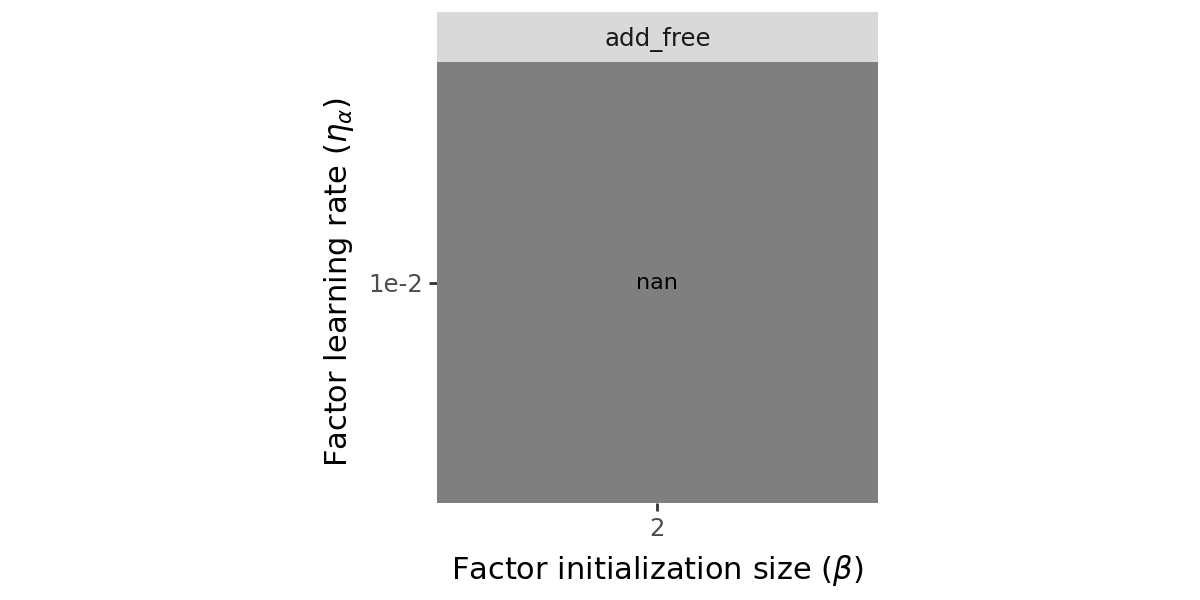

In [16]:
from plotnine import ggplot, aes, geom_tile, geom_text, labs, theme, scale_y_discrete


plot_df = (
    res_df.groupby(["method", "factor_lr", "factor_init"])
    .agg(
        acc=("acc", "mean"),
        std=("acc", "std"),
    )
    .reset_index()
)

plot_df['text'] = plot_df['std'].apply(lambda x: f"{x:.2f}")

plot_df['factor_lr'] = plot_df['factor_lr'].apply(lambda s: float(s))
plot_df["factor_lr"] = pd.Categorical(
    plot_df["factor_lr"],
    categories=sorted(plot_df["factor_lr"].unique()),
    ordered=True,
)
plot_df["factor_init"] = pd.Categorical(
    plot_df["factor_init"],
    categories=sorted(plot_df["factor_init"].unique()),
    ordered=True,
)

plot = (
    ggplot(plot_df, aes(x="factor_init", y="factor_lr", fill="std"))
    + geom_tile()
    + geom_text(aes(label="text"), size=8)
    + facet_wrap('method')
    + labs(
        x="Factor initialization size ($\\beta$)",
        y="Factor learning rate ($\\eta_\\alpha$)",
        fill="Std",
    )
    + theme(figure_size=(6, 3))
    + scale_y_discrete(
        labels=lambda lst: [
            f"{x:.1e}".replace("e-0", "e-").replace(".0", "") if x < 1 else f"{x}"
            for x in lst
        ],
    )
    + scale_fill_gradient(low='steelblue', high='white')
    + coord_equal()
)
plot


In [2]:
from datasets import load_dataset

ds = load_dataset('/mnt/data/byt/Dataset/tinyBenchmarks/tinyMMLU', split='test')
ds[0]


Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/285 [00:00<?, ? examples/s]

{'question': 'The number of days it takes to build a new house has a variance of 386. A sample of 40 new homes shows an average building time of 83 days. With what confidence can we assert that the average building time for a new house is between 80 and 90 days?',
 'subject': 'high_school_statistics',
 'choices': ['15.4%', '17.8%', '20.0%', '82.1%'],
 'answer': 3,
 'input_formatted': "The following are multiple choice questions (with answers) about high school statistics.\n\nWhich of the following is a correct statement about correlation?\nA. If the slope of the regression line is exactly 1, then the correlation is exactly 1.\nB. If the correlation is 0, then the slope of the regression line is undefined.\nC. Switching which variable is called x and which is called y changes the sign of the correlation.\nD. The correlation r is equal to the slope of the regression line when z-scores for the y-variable are plotted against z-scores for the x-variable.\nAnswer: D\n\nSuppose X and Y are ra

In [23]:
import re

pairs = ds[17]['input_formatted'].split('Answer:')
pairs
# for p in pairs[1:-1]:
#     few_shot_q = re.findall(r'(.*)Answer:', p, re.DOTALL)[0]
#     few_shot_a = re.findall(r'Answer: .*', p, re.DOTALL)
#     print(few_shot_q)


['The following are multiple choice questions (with answers) about college medicine.\n\nGlucose is transported into the muscle cell:\nA. via protein transporters called GLUT4.\nB. only in the presence of insulin.\nC. via hexokinase.\nD. via monocarbylic acid transporters.\n',
 ' A\n\nWhich of the following is not a true statement?\nA. Muscle glycogen is broken down enzymatically to glucose-1-phosphate\nB. Elite endurance runners have a high proportion of Type I fibres in their leg muscles\nC. Liver glycogen is important in the maintenance of the blood glucose concentration\nD. Insulin promotes glucose uptake by all tissues in the body\n',
 ' D\n\nIn a genetic test of a newborn, a rare genetic disorder is found that has X-linked recessive transmission. Which of the following statements is likely true regarding the pedigree of this disorder?\nA. All descendants on the maternal side will have the disorder.\nB. Females will be approximately twice as affected as males in this family.\nC. Al

In [29]:
task_desc = re.findall(r'The following .*\n', pairs[0])[0]
q1 = pairs[0].replace(task_desc, '').strip()
p = pairs[0]
few_shot_q = p.replace(task_desc, '').strip()
few_shot_q


'Glucose is transported into the muscle cell:\nA. via protein transporters called GLUT4.\nB. only in the presence of insulin.\nC. via hexokinase.\nD. via monocarbylic acid transporters.'

In [1]:
from datasets import load_dataset

ds = load_dataset('/home/byt/Dataset/google-research-datasets/mbpp', split='prompt')
ds[0]


Generating train split:   0%|          | 0/374 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/90 [00:00<?, ? examples/s]

Generating prompt split:   0%|          | 0/10 [00:00<?, ? examples/s]

{'task_id': 1,
 'text': 'Write a function to find the minimum cost path to reach (m, n) from (0, 0) for the given cost matrix cost[][] and a position (m, n) in cost[][].',
 'code': 'R = 3\r\nC = 3\r\ndef min_cost(cost, m, n): \r\n\ttc = [[0 for x in range(C)] for x in range(R)] \r\n\ttc[0][0] = cost[0][0] \r\n\tfor i in range(1, m+1): \r\n\t\ttc[i][0] = tc[i-1][0] + cost[i][0] \r\n\tfor j in range(1, n+1): \r\n\t\ttc[0][j] = tc[0][j-1] + cost[0][j] \r\n\tfor i in range(1, m+1): \r\n\t\tfor j in range(1, n+1): \r\n\t\t\ttc[i][j] = min(tc[i-1][j-1], tc[i-1][j], tc[i][j-1]) + cost[i][j] \r\n\treturn tc[m][n]',
 'test_list': ['assert min_cost([[1, 2, 3], [4, 8, 2], [1, 5, 3]], 2, 2) == 8',
  'assert min_cost([[2, 3, 4], [5, 9, 3], [2, 6, 4]], 2, 2) == 12',
  'assert min_cost([[3, 4, 5], [6, 10, 4], [3, 7, 5]], 2, 2) == 16'],
 'test_setup_code': '',
 'challenge_test_list': []}

In [6]:
MBPP_TEMPLATE = """You are an expert Python programmer, and here is your task: {text} Your code should pass these tests:
{test_list_0}
{test_list_1}
{test_list_2} """
rec = ds[0]
prompt = MBPP_TEMPLATE.format(text=rec['text'], test_list_0=rec['test_list'][0], test_list_1=rec['test_list'][1], test_list_2=rec['test_list'][2])
print(prompt)


You are an expert Python programmer, and here is your task: Write a function to find the minimum cost path to reach (m, n) from (0, 0) for the given cost matrix cost[][] and a position (m, n) in cost[][]. Your code should pass these tests:
assert min_cost([[1, 2, 3], [4, 8, 2], [1, 5, 3]], 2, 2) == 8
assert min_cost([[2, 3, 4], [5, 9, 3], [2, 6, 4]], 2, 2) == 12
assert min_cost([[3, 4, 5], [6, 10, 4], [3, 7, 5]], 2, 2) == 16 


# 2D figure

In [16]:
from collections import defaultdict
import pandas as pd


def get_results():
    df = defaultdict(list)

    df['method'].extend(['Prompt']*3)
    df['objective'].extend(['none']*3)
    df['MMLU accuracy'].extend([53.7, 62.1, 63.8])
    df['GSM8K accuracy'].extend([61, 88.6, 93.4])
    df['Overall score'].extend([0.10, 0.08, 0.13])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['100%']*3)

    df['method'].extend(['FSSV']*3)
    df['objective'].extend(['Lang']*3)
    df['MMLU accuracy'].extend([41.5, 54.2, 41.1])
    df['GSM8K accuracy'].extend([10.7, 8.6, 6.6])
    df['Overall score'].extend([0.59, 0.79, 0.91])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['100%']*3)

    df['method'].extend(['FSSV']*3)
    df['objective'].extend(['Lang']*3)
    df['MMLU accuracy'].extend([42.5, 67.2, 51.5])
    df['GSM8K accuracy'].extend([16.7, 32.4, 36])
    df['Overall score'].extend([0.304, 0.328, 0.665])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['80%']*3)

    df['method'].extend(['FSSV']*3)
    df['objective'].extend(['Lang']*3)
    df['MMLU accuracy'].extend([49.8, 71.4, 62.7])
    df['GSM8K accuracy'].extend([33.6, 75.2, 82.0])
    df['Overall score'].extend([0.095, 0.124, 0.149])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['50%']*3)

    df['method'].extend(['PrOSV']*3)
    df['objective'].extend(['Lang']*3)
    df['MMLU accuracy'].extend([52.9, 55.4, 58.4])
    df['GSM8K accuracy'].extend([50.5, 68.4, 78.2])
    df['Overall score'].extend([0.43, 0.58, 0.71])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['100%']*3)

    df['method'].extend(['FSSV']*3)
    df['objective'].extend(['SimPO']*3)
    df['MMLU accuracy'].extend([37.8, 41.3, 39.2])
    df['GSM8K accuracy'].extend([5.6, 4.2, 6.9])
    df['Overall score'].extend([0.74, 0.85, 0.93])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['100%']*3)

    df['method'].extend(['FSSV']*3)
    df['objective'].extend(['SimPO']*3)
    df['MMLU accuracy'].extend([38.7, 60.3, 49.0])
    df['GSM8K accuracy'].extend([10.7, 20.8, 26])
    df['Overall score'].extend([0.433, 0.512, 0.716])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['80%']*3)

    df['method'].extend(['FSSV']*3)
    df['objective'].extend(['SimPO']*3)
    df['MMLU accuracy'].extend([48.8, 67.7, 62.1])
    df['GSM8K accuracy'].extend([28.4, 59.1, 77.6])
    df['Overall score'].extend([0.049, 0.171, 0.141])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['50%']*3)

    df['method'].extend(['PrOSV']*3)
    df['objective'].extend(['SimPO']*3)
    df['MMLU accuracy'].extend([51.3, 56.2, 59.2])
    df['GSM8K accuracy'].extend([50.3, 66.8, 79.2])
    df['Overall score'].extend([0.46, 0.60, 0.78])
    df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
    df["Factor"].extend(['100%']*3)

    df = pd.DataFrame(df)
    return df


In [17]:
vanilla_df = defaultdict(list)
vanilla_df['method'].extend(['Vanilla']*3)
vanilla_df['objective'].extend(['none']*3)
vanilla_df['MMLU accuracy'].extend([54, 74, 74])
vanilla_df['GSM8K accuracy'].extend([79, 93, 97])
vanilla_df['Overall score'].extend([0, 0, 0])
vanilla_df["Model"].extend(["Gemma2-2B", "Gemma2-9B", "Qwen2.5-32B"])
vanilla_df["Factor"].extend(['100%']*3)
vanilla_df = pd.DataFrame(vanilla_df)

vanilla_df['Accuracy'] = (vanilla_df["GSM8K accuracy"] + vanilla_df['MMLU accuracy']) / 2

vanilla_df["method_objective"] = [f"{x['method']}" for _, x in vanilla_df.iterrows()]
vanilla_df["method_objective"] = pd.Categorical(
    vanilla_df["method_objective"],
    categories=["Vanilla"],
    ordered=True,
)


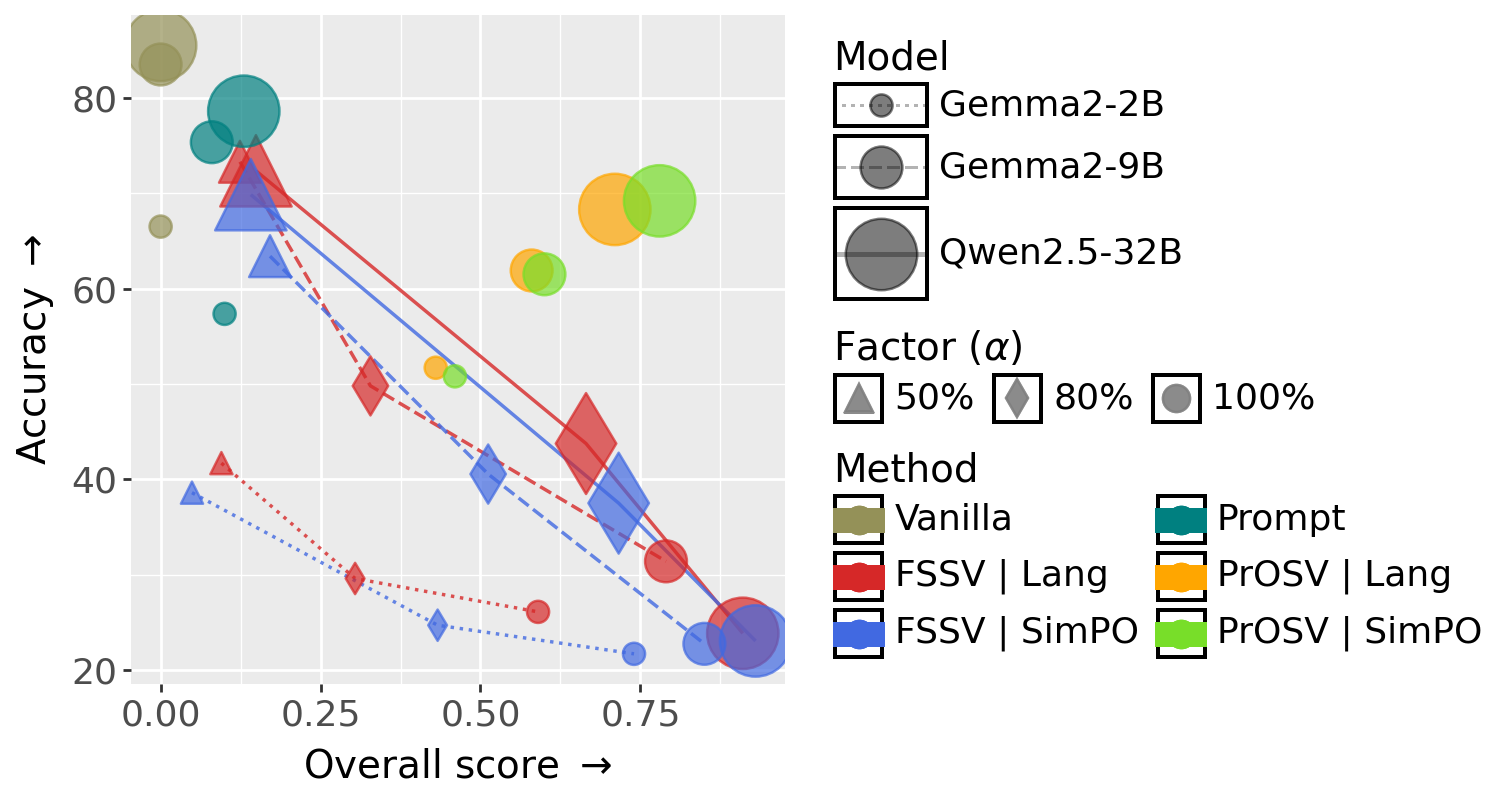

In [21]:
import plotnine.geoms
plotnine.geoms.geom_line.DEFAULT_AES['linewidth'] = 50.0
from plotnine import *


df = get_results()

df['Accuracy'] = (df["GSM8K accuracy"] + df['MMLU accuracy']) / 2

# def harmonic_mean(scores):
#     # Return 0 if any score is 0 to maintain strict evaluation
#     if 0 in scores:
#         return 0.0
#     return len(scores) / sum(1 / s for s in scores)

# df['Accuracy'] = [harmonic_mean([g, m]) for g, m in zip(df['GSM8K accuracy'].tolist(), df['MMLU accuracy'].tolist())]

df["method_objective"] = [
    f"{x['method']} | {x['objective']}"
    if x["objective"] != "none"
    else f"{x['method']}"
    for _, x in df.iterrows()
]
df["method_objective"] = pd.Categorical(
    df["method_objective"],
    categories=[
        "FSSV | Lang",
        "FSSV | SimPO",
        "Prompt",
        "PrOSV | Lang",
        "PrOSV | SimPO",
    ],
    ordered=True,
)
df['Factor'] = pd.Categorical(df['Factor'], categories=['50%', '80%', '100%'], ordered=True)

colors = [
    "#949158",
    "#d62828",
    # "#3a5cac",
    "royalblue",
    # "indigo",
    "teal",
    "#ffa600",
    "#78de29",
    "#fee529",
    "#39a9bc",
    "#972d9b",
]

# plot = (
#     ggplot(
#         df, aes(x="Overall score", y="Accuracy", color="method_objective", size='Model', alpha='Factor')
#     )
#     + geom_point()
#     + scale_size_manual([4, 7, 10])
#     + scale_alpha_manual([0.9, 0.3])
#     + scale_color_manual(colors)
#     + labs(color='Method', x='Overall score $\\rightarrow$', y='Accuracy $\\rightarrow$')
#     + theme(
#         figure_size=(6,4),
#         legend_box='vertical',
#         legend_key=element_rect(color="black", fill="white", size=0.8),
#         # legend_key=element_rect(color="white", fill="white", size=0.8),
#         legend_text=element_text(size=12),
#         legend_title=element_text(size=14),
#         legend_justification='left',
#         axis_text=element_text(size=11),
#         axis_title=element_text(size=14),
#     )
#     + guides(color=guide_legend(override_aes={'size': 5, 'alpha': 1}), alpha='none')
# )
# plot

df_plot = df.copy()
df_plot["group_key"] = df_plot["method"] + "|" + df_plot["Model"] + "|" + df_plot["objective"]
# df_plot = df_plot.sort_values(["group_key", "Overall score"]).reset_index(drop=True)


plot = (
    ggplot(
        df_plot,
        aes(
            x="Overall score",
            y="Accuracy",
            color="method_objective",
            size="Model",
            shape="Factor",
        ),
    )
    + geom_line(aes(group="group_key", linetype="Model"), size=0.7, alpha=0.8)
    + geom_point(alpha=0.7)
    + scale_size_manual([4, 8, 14])
    # + scale_alpha_manual([0.1, 0.4, 1.0])
    + scale_shape_manual(["^", "d", "o"])
    + scale_linetype_manual(["dotted", "dashed", "solid"])
    + scale_color_manual(colors)
    + labs(
        color="Method", x="Overall score $\\rightarrow$", y="Accuracy $\\rightarrow$"
    )
    + theme(
        figure_size=(7.5, 4),
        legend_box="vertical",
        legend_key=element_rect(color="black", fill="white", size=0.8),
        legend_text=element_text(size=13),
        legend_title=element_text(size=14),
        axis_text=element_text(size=13),
        axis_title=element_text(size=14),
        legend_position="right",
        legend_box_just="left",
    )
    + guides(
        color=guide_legend(override_aes={"size": 5, "alpha": 1}, ncol=2, order=3),
        shape=guide_legend(
            title="Factor ($\\alpha$)",
            override_aes={"size": 5, "color": "gray"},
            ncol=3,
            order=2,
        ),
        size=guide_legend(order=1, override_aes={"alpha": 0.3}),
    )
    + geom_point(vanilla_df, aes(x="Overall score", y="Accuracy"), alpha=0.7)
    # + theme_bw()
)
plot


In [23]:
# import plotnine.geoms
# plotnine.geoms.geom_line.DEFAULT_AES['linewidth'] = 50.0
# from plotnine import *


# df = get_results()

# df['Accuracy'] = (df["GSM8K accuracy"] + df['MMLU accuracy']) / 2

# df["method_objective"] = [
#     f"{x['method']} | {x['objective']}"
#     if x["objective"] != "none"
#     else f"{x['method']}"
#     for _, x in df.iterrows()
# ]
# df["method_objective"] = pd.Categorical(
#     df["method_objective"],
#     categories=[
#         "FSSV | Lang",
#         "FSSV | SimPO",
#         "Prompt",
#         "PrOSV | Lang",
#         "PrOSV | SimPO",
#     ],
#     ordered=True,
# )
# df['Factor'] = pd.Categorical(df['Factor'], categories=['50%', '80%', '100%'], ordered=True)

# colors = [
#     "#949158",
#     "#d62828",
#     "#3a5cac",
#     "indigo",
#     "#ffa600",
#     "#78de29",
#     "#fee529",
#     "#39a9bc",
#     "#972d9b",
# ]

# df_plot = df.copy()
# df_plot["group_key"] = df_plot["method"] + "|" + df_plot["Model"] + "|" + df_plot["objective"]

# plot = (
#     ggplot(
#         df_plot,
#         aes(
#             x="Overall score",
#             y="Accuracy",
#             color="method_objective",
#             # size="Model",
#             shape="Factor",
#         ),
#     )
#     + facet_wrap('Model', nrow=2, ncol=2)
#     # + geom_line(aes(group="group_key", linetype="Model"), size=0.7, alpha=0.8)
#     + geom_line(aes(group="group_key"), size=0.7, alpha=0.8)
#     + geom_point(alpha=0.5, size=10)
#     + scale_size_manual([4, 8, 14])
#     # + scale_alpha_manual([0.1, 0.4, 1.0])
#     + scale_shape_manual(["^", "d", "o"])
#     + scale_linetype_manual(["dotted", "dashed", "solid"])
#     + scale_color_manual(colors)
#     + labs(
#         color="Method", x="Overall score $\\rightarrow$", y="Accuracy $\\rightarrow$"
#     )
#     + theme(
#         figure_size=(7.5, 6),
#         legend_box="vertical",
#         legend_key=element_rect(color="black", fill="white", size=0.8),
#         legend_text=element_text(size=13),
#         legend_title=element_text(size=14),
#         axis_text=element_text(size=13),
#         axis_title=element_text(size=14),
#         # legend_position="right",
#         legend_box_just="left",
#         legend_position=(1.0, 0.1),
#         strip_text=element_text(size=12)
#     )
#     + guides(
#         color=guide_legend(override_aes={"size": 5, "alpha": 1}, ncol=2, order=3),
#         shape=guide_legend(
#             title="Factor ($\\alpha$)",
#             override_aes={"size": 5, "color": "gray"},
#             ncol=3,
#             order=2,
#         ),
#         # size=guide_legend(order=1, override_aes={"alpha": 0.3}),
#     )
#     + geom_point(vanilla_df, aes(x="Overall score", y="Accuracy"), alpha=0.7, size=10)
#     # + theme_bw()
# )
# plot


In [23]:
# from pathlib import Path

# save_dir = Path("figures/")
# save_dir.mkdir(parents=True, exist_ok=True)
# save_path = save_dir / "tradeoff_robustness_vs_utility.pdf"
# plot.save(save_path)


## Per-model figure

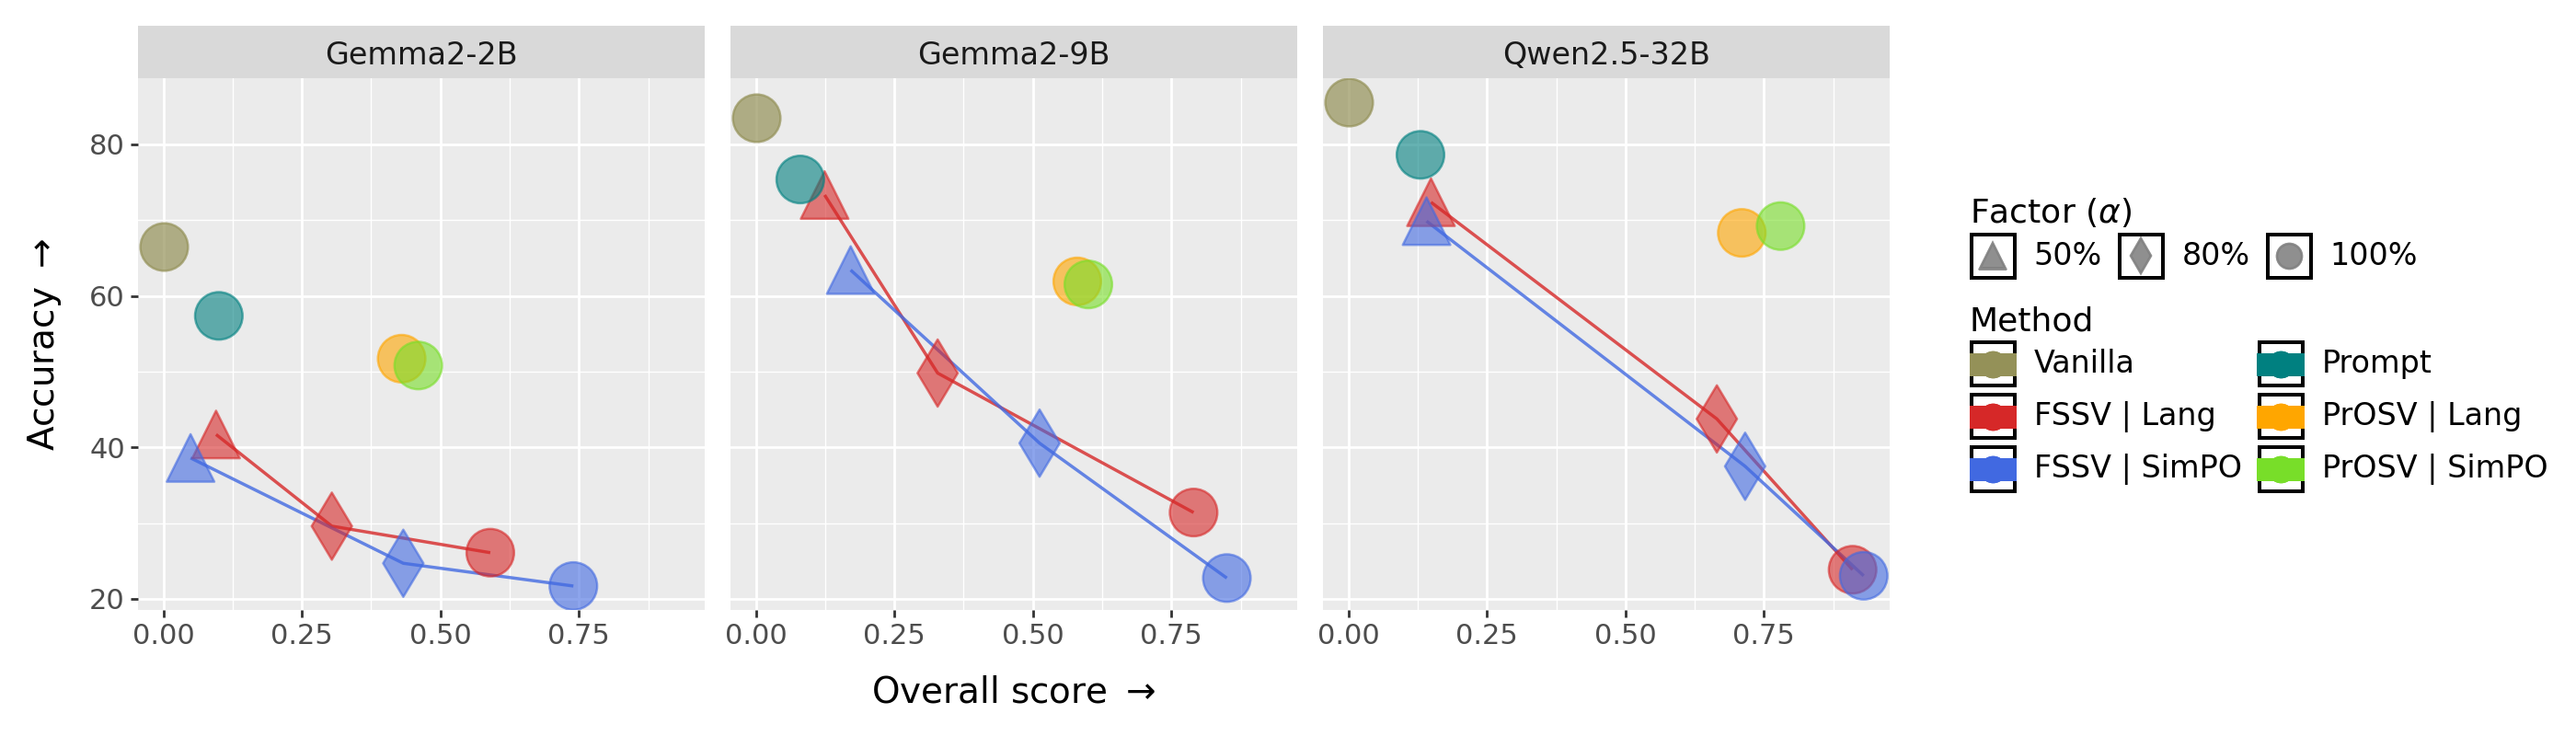

In [24]:
import plotnine.geoms
plotnine.geoms.geom_line.DEFAULT_AES['linewidth'] = 50.0
from plotnine import *


df = get_results()

df['Accuracy'] = (df["GSM8K accuracy"] + df['MMLU accuracy']) / 2

# def harmonic_mean(scores):
#     # Return 0 if any score is 0 to maintain strict evaluation
#     if 0 in scores:
#         return 0.0
#     return len(scores) / sum(1 / s for s in scores)

# df['Accuracy'] = [harmonic_mean([g, m]) for g, m in zip(df['GSM8K accuracy'].tolist(), df['MMLU accuracy'].tolist())]

df["method_objective"] = [
    f"{x['method']} | {x['objective']}"
    if x["objective"] != "none"
    else f"{x['method']}"
    for _, x in df.iterrows()
]
df["method_objective"] = pd.Categorical(
    df["method_objective"],
    categories=[
        "FSSV | Lang",
        "FSSV | SimPO",
        "Prompt",
        "PrOSV | Lang",
        "PrOSV | SimPO",
    ],
    ordered=True,
)
df['Factor'] = pd.Categorical(df['Factor'], categories=['50%', '80%', '100%'], ordered=True)

colors = [
    "#949158",
    "#d62828",
    # "#3a5cac",
    "royalblue",
    "teal",
    "#ffa600",
    "#78de29",
    "#fee529",
    "#39a9bc",
    "#972d9b",
]

# plot = (
#     ggplot(
#         df, aes(x="Overall score", y="Accuracy", color="method_objective", size='Model', alpha='Factor')
#     )
#     + geom_point()
#     + scale_size_manual([4, 7, 10])
#     + scale_alpha_manual([0.9, 0.3])
#     + scale_color_manual(colors)
#     + labs(color='Method', x='Overall score $\\rightarrow$', y='Accuracy $\\rightarrow$')
#     + theme(
#         figure_size=(6,4),
#         legend_box='vertical',
#         legend_key=element_rect(color="black", fill="white", size=0.8),
#         # legend_key=element_rect(color="white", fill="white", size=0.8),
#         legend_text=element_text(size=12),
#         legend_title=element_text(size=14),
#         legend_justification='left',
#         axis_text=element_text(size=11),
#         axis_title=element_text(size=14),
#     )
#     + guides(color=guide_legend(override_aes={'size': 5, 'alpha': 1}), alpha='none')
# )
# plot

df_plot = df.copy()
# df_plot = df_plot[df_plot['Model']==model]
df_plot["group_key"] = df_plot["method"] + "|" + df_plot["objective"]


plot = (
    ggplot(
        df_plot,
        aes(
            x="Overall score",
            y="Accuracy",
            color="method_objective",
            shape="Factor",
        ),
    )
    + facet_wrap('Model')
    + geom_line(aes(group="group_key"), size=0.7, alpha=0.8)
    + geom_point(alpha=0.6, size=10)
    # + scale_size_manual([4, 8, 14])
    # + scale_alpha_manual([0.1, 0.4, 1.0])
    + scale_shape_manual(["^", "d", "o"])
    # + scale_linetype_manual(['dotted', 'dashed', 'solid'])
    + scale_color_manual(colors)
    + labs(
        color="Method", x="Overall score $\\rightarrow$", y="Accuracy $\\rightarrow$"
    )
    + theme(
        figure_size=(14, 4),
        legend_box="vertical",
        legend_key=element_rect(color="black", fill="white", size=0.8),
        legend_text=element_text(size=12),
        legend_title=element_text(size=13),
        axis_text=element_text(size=11),
        axis_title=element_text(size=14),
        legend_position="right",
        legend_box_just="left",
        strip_text=element_text(size=12)
    )
    + guides(
        color=guide_legend(override_aes={"size": 5, "alpha": 1}, ncol=2, order=3),
        shape=guide_legend(
            title="Factor ($\\alpha$)",
            override_aes={"size": 5, "color": "gray"},
            ncol=3,
            order=2,
        ),
        # size=guide_legend(order=1, override_aes={"alpha": 0.3}),
    )
    + geom_point(vanilla_df, aes(x="Overall score", y="Accuracy"), alpha=0.7, size=10)
    # + theme_bw()
)
plot


In [ ]:
# from pathlib import Path

# save_dir = Path("figures/")
# save_dir.mkdir(parents=True, exist_ok=True)

# # save_path = save_dir / f"tradeoff_robustness_vs_utility_{model}.pdf"

# save_path = save_dir / "tradeoff_robustness_vs_utility_per_model.pdf"

# plot.save(save_path)


/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 4 in image.
/home/byt/Code/reft/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/tradeoff_robustness_vs_utility_per_model.pdf


# AxBench scores

In [844]:
import pandas as pd
from pathlib import Path

benchmark_name = "tinygsm8k"

cfg = "2b_l10"
cfg = "9b_l20"
cfg = "q25_32b_l32"

positions = "all"
positions = "f2+l2"

obj = "lang"
obj = "simpo"

intvs = ["add_free"]

# positions = "prompt"
# obj = "none"
# intvs = ["prompt"]

output_root_dir = Path("/mnt/data/byt", "reft_data", "benchmark")


In [ ]:
from collections import defaultdict
import itertools
import numpy as np


def harmonic_mean(scores):
    # Return 0 if any score is 0 to maintain strict evaluation
    if 0 in scores:
        return 0.0
    return len(scores) / sum(1 / s for s in scores)


def get_overall_score_concept_df(eval_df: pd.DataFrame):
    harmonic_scores = []
    for _, row in eval_df.iterrows():
        mean = harmonic_mean(
            [row["concept_score"], row["relevance_score"], row["fluency_score"]]
        )
        harmonic_scores.append(mean)

    return np.mean(harmonic_scores).item()


def load_results(output_root_dir, cfgs, positions, objs, interventions=("add_free", )):
    res_df = defaultdict(list)

    for k, cfg, obj, pos in itertools.product(interventions, cfgs, objs, positions):
        for concept_id in range(100):
            eval_path = (
                output_root_dir
                / cfg
                / f"outputs_{k}"
                / f"{pos}"
                / obj
                / f"{concept_id}"
                / f"eval_{benchmark_name}.parquet"
            )
            if not eval_path.exists():
                continue

            eval_df = pd.read_parquet(eval_path)

            overall_score = get_overall_score_concept_df(eval_df)
            concept_score = eval_df["concept_score"].mean()
            instruct_score = eval_df["relevance_score"].mean()
            fluency_score = eval_df["fluency_score"].mean()

            res_df["method"].append(k)
            res_df["cfg"].append(cfg)
            res_df["objective"].append(obj)
            res_df["position"].append(pos)

            res_df["concept_id"].append(concept_id)
            res_df["concept"].append(eval_df["concept"].iloc[0])
            res_df["overall_score"].append(overall_score)
            res_df["concept_score"].append(concept_score)
            res_df["instruct_score"].append(instruct_score)
            res_df["fluency_score"].append(fluency_score)

    res_df = pd.DataFrame(res_df)
    if len(res_df) == 0:
        return None
    res_df["method"] = res_df["method"].replace(
        ["add_free", "clamp_free"], ["AddInv", "ClampInv"]
    )
    return res_df


In [ ]:
res_df = load_results(
    output_root_dir=output_root_dir,
    cfgs=[cfg],
    positions=[positions],
    objs=[obj],
    interventions=intvs,
)
res_df


In [847]:
score_keys = ("overall", "concept", "instruct", "fluency")
for k in score_keys:
    score = res_df[f"{k}_score"].mean()
    std = res_df[f"{k}_score"].std()
    print(f"{k.capitalize()} score:\t{score:.4f} ± {std:.4f}")


Overall score:	0.8924 ± 0.4735
Concept score:	0.8460 ± 0.5374
Instruct score:	1.9380 ± 0.0791
Fluency score:	1.3100 ± 0.2113


In [848]:
score_keys = ("overall", "concept", "instruct", "fluency")
for k in score_keys:
    score = res_df[f"{k}_score"].iloc[2:].mean()
    std = res_df[f"{k}_score"].std()
    print(f"{k.capitalize()} score:\t{score:.4f} ± {std:.4f}")


Overall score:	1.0735 ± 0.4735
Concept score:	1.0225 ± 0.5374
Instruct score:	1.9225 ± 0.0791
Fluency score:	1.3125 ± 0.2113
